# Assignment 5 (29th May)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 5.1: Variational Autoencoder (35 points)
Implement VAE from scratch in PyTorch:

• Train on Fashion-MNIST dataset.

• Implement reparameterization trick correctly.

• Visualize latent space in 2D using t-SNE.

• Generate new samples by sampling from latent distribution.

• Perform latent space interpolation between pairs of images.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

import numpy as np 
import keras as K
from keras.layers import Dense, Flatten
import tensorflow as tf

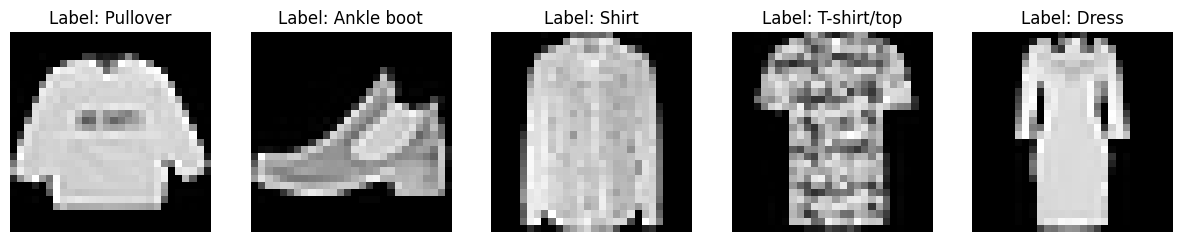

In [4]:
# load fashion mnist dataset from data
train = pd.read_csv('data/fashion-mnist_train.csv')
test = pd.read_csv('data/fashion-mnist_test.csv')

X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values
X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

labels = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# visualize some examples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {labels[train.iloc[i, 0]]}')
    axes[i].axis('off')
plt.show()

In [ ]:
# Custom VAE model
class VAE(K.models.Model):
    def __init__(self, hidden_dim=128, latent_dim=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.flatten = Flatten()
        self.encoder_dense = Dense(hidden_dim, activation='relu')
        self.mu_layer = Dense(latent_dim)
        self.log_var_layer = Dense(latent_dim)
        self.decoder_dense = Dense(hidden_dim, activation='relu')
        self.decoder_out = Dense(784, activation='sigmoid')

    def encode(self, x):
        x = self.flatten(x)
        h = self.encoder_dense(x)
        mu = self.mu_layer(h)
        log_var = self.log_var_layer(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        eps = tf.random.normal(shape=tf.shape(mu))
        sigma = tf.exp(0.5 * log_var)
        return mu + sigma * eps

    def decode(self, z):
        h = self.decoder_dense(z)
        return self.decoder_out(h)

    def call(self, inputs, training=False):
        mu, log_var = self.encode(inputs)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

    def _compute_loss(self, x, recon, mu, log_var):
        x_flat = tf.reshape(x, (-1, 784))
        recon_flat = tf.reshape(recon, (-1, 784))
        # Binary cross-entropy loss for reconstruction
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.nn.sigmoid_cross_entropy_with_logits(labels=x_flat, logits=recon_flat), axis=-1))
        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=-1))
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            recon, mu, log_var = self(x, training=True)
            total_loss, recon_loss, kl_loss = self._compute_loss(x, recon, mu, log_var)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        recon, mu, log_var = self(x, training=False)
        total_loss, recon_loss, kl_loss = self._compute_loss(x, recon, mu, log_var)
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

# reshape inputs to 28x28
X_train_img = X_train.reshape(-1, 28, 28) / 255.0
X_test_img = X_test.reshape(-1, 28, 28) / 255.0

vae = VAE(hidden_dim=128, latent_dim=5)
vae.compile(optimizer='adam')
# Only pass images (X_train_img), not labels - VAE is unsupervised
history = vae.fit(X_train_img, epochs=50, batch_size=128, validation_data=X_test_img)


Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 3.6804 - loss: 532.2220 - reconstruction_loss: 528.5416 - val_kl_loss: 3.5962 - val_loss: 537.5912 - val_reconstruction_loss: 533.9951
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.3689 - loss: 529.2272 - reconstruction_loss: 525.8583 - val_kl_loss: 3.3895 - val_loss: 531.4932 - val_reconstruction_loss: 528.1037
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 3.5718 - loss: 526.7349 - reconstruction_loss: 523.1631 - val_kl_loss: 3.1572 - val_loss: 531.7662 - val_reconstruction_loss: 528.6089
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 3.5200 - loss: 528.4168 - reconstruction_loss: 524.8968 - val_kl_loss: 3.3185 - val_loss: 530.2811 - val_reconstruction_loss: 526.9626
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 4.1175 - loss: 524.9099 - reconstruction_loss: 520.7924 - val_kl_loss: 3.6078 - val_loss: 529.2340 - val_reconstruction_loss: 525.6262
Epoch 6/50

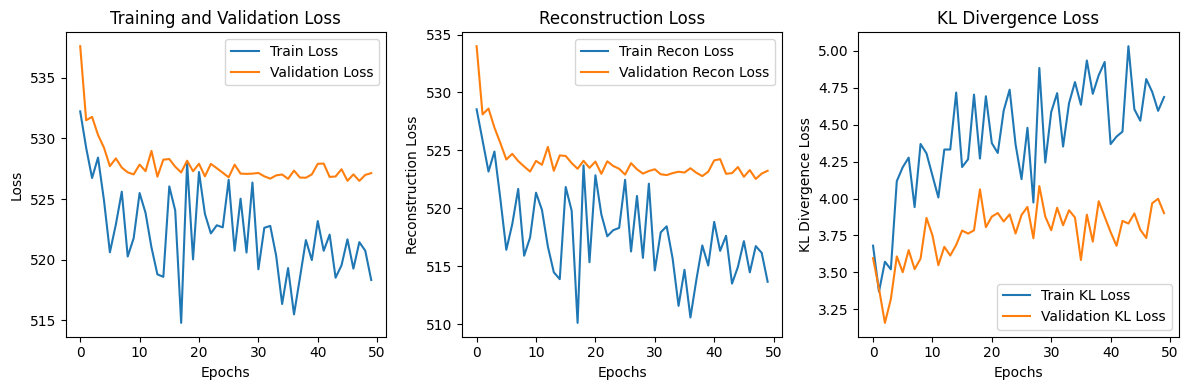

In [6]:
# plot train and validation loss, reconstruction loss and KL divergence loss
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Training and Validation Loss')
axes[1].plot(history.history['reconstruction_loss'], label='Train Recon Loss')
axes[1].plot(history.history['val_reconstruction_loss'], label='Validation Recon Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].legend()
axes[1].set_title('Reconstruction Loss')
axes[2].plot(history.history['kl_loss'], label='Train KL Loss')
axes[2].plot(history.history['val_kl_loss'], label='Validation KL Loss')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('KL Divergence Loss')
axes[2].legend()
axes[2].set_title('KL Divergence Loss')
plt.tight_layout()
plt.show()

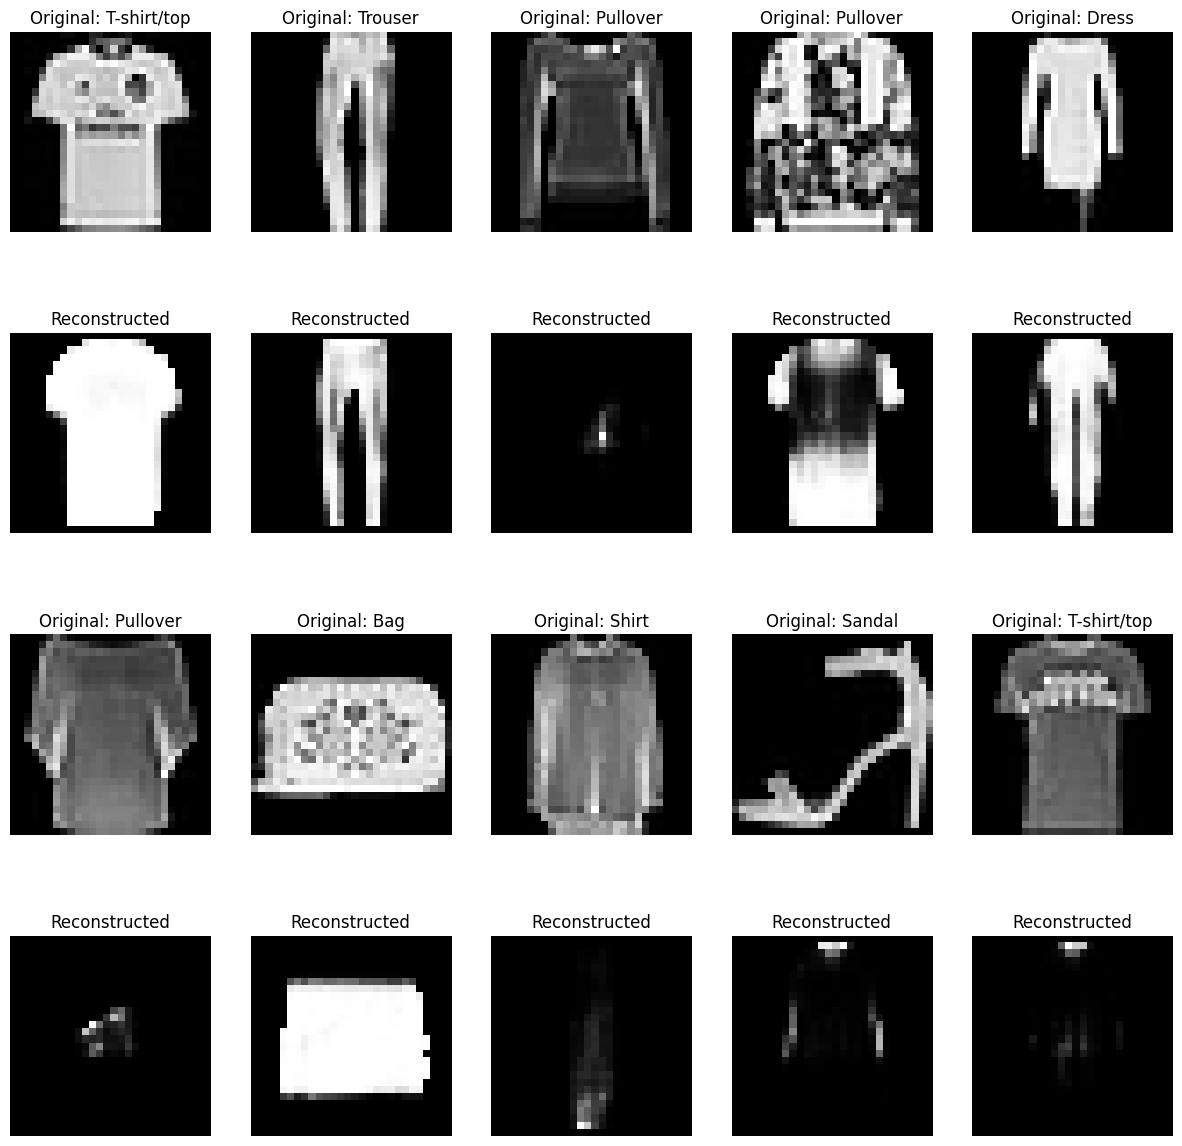

In [7]:
# pass several images from test set through the VAE to get reconstructions and latent variables
recon, mu, log_var = vae(X_test_img[:10])
# plot original and reconstructed images
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(15, 15))
for i in range(10):
    # Original image
    axes[2*(i // 5), i % 5].imshow(X_test_img[i], cmap='gray')
    axes[2*(i // 5), i % 5].set_title(f'Original: {labels[y_test[i]]}')
    axes[2*(i // 5), i % 5].axis('off')
    # Reconstructed image
    recon_img = recon[i].numpy().reshape(28, 28)
    axes[2*(i // 5) + 1, i % 5].imshow(recon_img, cmap='gray')
    axes[2*(i // 5) + 1, i % 5].set_title('Reconstructed')
    axes[2*(i // 5) + 1, i % 5].axis('off')

plt.show()

The model can reconstruct the shapes of the images which in a distinguishable way, but the details are blurry. This applies only when a high contrast is observed in the image. The reconstruction of blouson is quite poor as it does not have a distinct light shape on the black background.

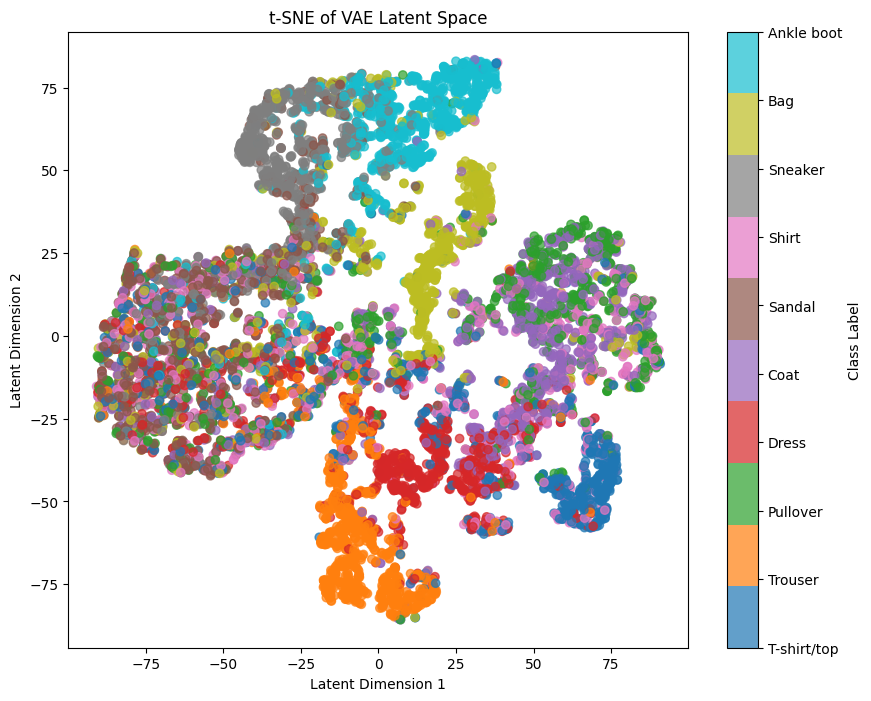

In [8]:
# visualize latent space with t-SNE
mu_test, _, _ = vae(X_test_img)
tsne = TSNE(n_components=2, random_state=42)
mu_2d = tsne.fit_transform(mu_test.numpy())
plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=y_test, cmap='tab10', alpha=0.7)
cbar = plt.colorbar(scatter, ticks=list(labels.keys()), label='Class Label')
cbar.ax.set_yticklabels([labels[k] for k in labels.keys()])
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('t-SNE of VAE Latent Space')
plt.show()

Some of the groups are easily separable in the latent space, while others are more mixed. For example, T-shirt/top and Shirt are quite close to each other, which makes sense as they have similar shapes. On the other hand, Trouser, Sneaker and Ankle boot are more separated from the rest, likely due to their distinct shapes.

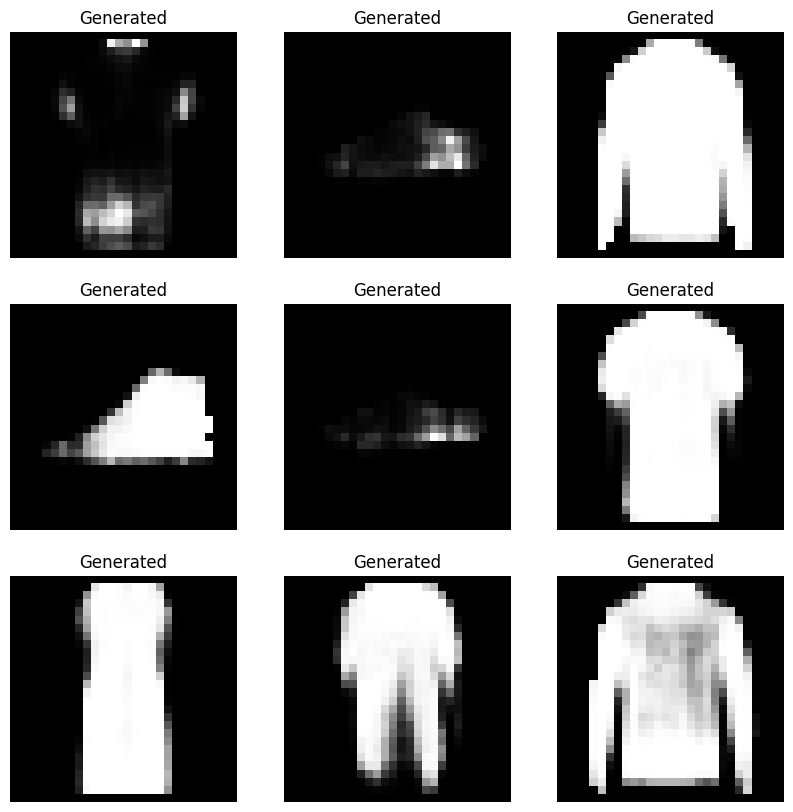

In [15]:
# generate new samples by sampling from the latent space
z_samples = np.random.normal(size=(10, 5))  # Sample 10 random points in the latent space
generated_imgs = vae.decode(z_samples).numpy().reshape(-1, 28, 28)
# plot generated images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(9):
    axes[i // 3, i % 3].imshow(generated_imgs[i], cmap='gray')
    axes[i // 3, i % 3].set_title('Generated')
    axes[i // 3, i % 3].axis('off')
plt.show()

Boots, dress, and shirts look sensible but some of the images do not have a clear shape and look like noise. This looks similar to the results obtained e.g. for blouson earlier.

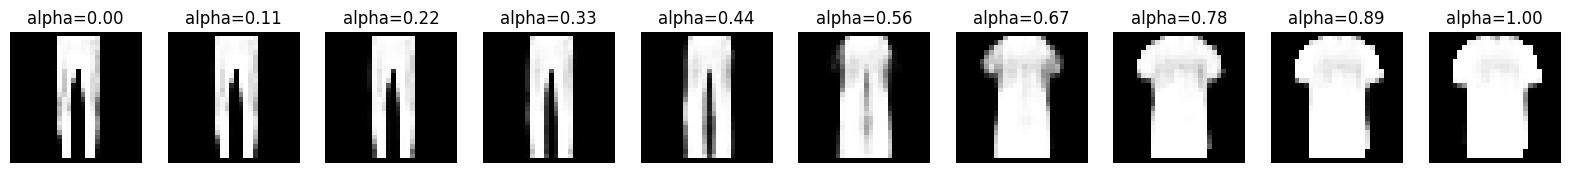

In [16]:
# perform latent space interpolation between pairs of images from test set
img1, img2 = X_test_img[0], X_test_img[1]
mu1, _ = vae.encode(img1[None, ...])
mu2, _ = vae.encode(img2[None, ...])

# Interpolate in latent space
alphas = np.linspace(0, 1, num=10)
interpolated_imgs = []
for alpha in alphas:
    z_interp = alpha * mu1 + (1 - alpha) * mu2
    recon_interp = vae.decode(z_interp).numpy()[0].reshape(28, 28)
    interpolated_imgs.append(recon_interp)

# plot interpolated images
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, img in enumerate(interpolated_imgs):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'alpha={alphas[i]:.2f}')
    axes[i].axis('off')
plt.show()

## Problem 5.2: GAN Implementation (35 points)
Build a DCGAN for image generation:

• Train on CIFAR-10 dataset.

• Implement proper generator and discriminator architectures.

• Monitor training stability using loss curves and Fr´echet Inception Dis-
tance.

• Generate grid of synthetic images throughout training.

• Discuss challenges encountered and solutions applied.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import torch.optim as optim

import ssl, certifi # Ensure that SSL certificates are properly handled for secure connections 
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import tensorflow as tf  # for dataset

from sklearn.preprocessing import MinMaxScaler
from torchmetrics.image.fid import FrechetInceptionDistance

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('Device: CUDA GPU -', torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('Device: Apple Silicon MPS')
else:
    device = torch.device('cpu')
    print('Device: CPU')

# Reproducibility seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Device: Apple Silicon MPS


In [44]:
# data loading
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
labels = {
    0: 'Airplane',
    1: 'Automobile',
    2: 'Bird',
    3: 'Cat',
    4: 'Deer',
    5: 'Dog',
    6: 'Frog',
    7: 'Horse',
    8: 'Ship',
    9: 'Truck'
}

/var/folders/xn/vc8pmh6d66q1wx71kjbk95rh0000gn/T/ipykernel_47018/3939584016.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(labels[int(y_train[i])], fontsize=9)


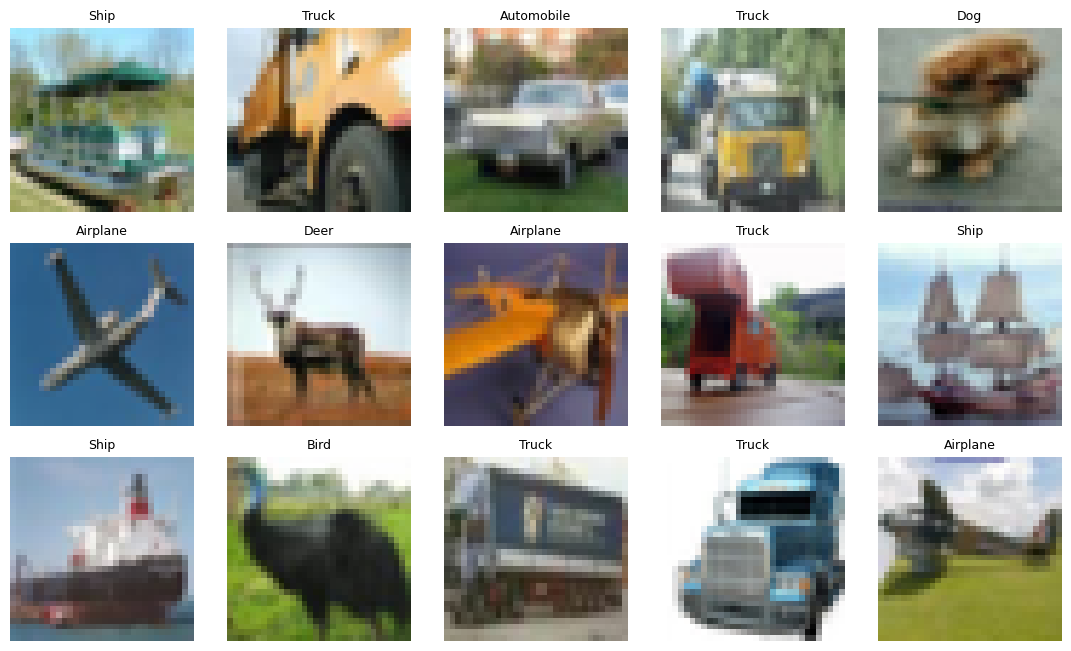

In [55]:
# Example CIFAR-10 gallery
rng = np.random.default_rng(SEED)
rows, cols = 3, 5
idx = rng.choice(len(X_train), size=rows * cols, replace=False)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i])
    ax.set_title(labels[int(y_train[i])], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [48]:
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 32*32*3)).reshape(-1, 32, 32, 3)
X_test_scaled = scaler.transform(X_test.reshape(-1, 32*32*3)).reshape(-1, 32, 32, 3)

In [5]:
# ---- DCGAN implementation ----
# We work with 32x32 images to keep training fast on CPU/MPS.
# Scaling to 64x64 requires only an extra ConvTranspose layer.

IMG_SIZE = 32
NC       = 3     # number of channels (1 = grayscale MNIST)
NGF      = 64    # generator feature map size
NDF      = 64    # discriminator feature map size
Z_DIM_DC = 100

def weights_init(m):
    """Initialise conv and batchnorm weights as in the DCGAN paper."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class DCGenerator(nn.Module):
    """
    Produces 1 x 32 x 32 images.
    Architecture: z -> [4x4] -> [8x8] -> [16x16] -> [32x32]
    """
    def __init__(self, z_dim, ngf, nc):
        super().__init__()
        self.main = nn.Sequential(
            # input: (z_dim, 1, 1)
            nn.ConvTranspose2d(z_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4, 4, 4)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2, 8, 8)
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # (ngf, 16, 16)
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # (nc, 32, 32)
        )

    def forward(self, z):
        # z must be (batch, z_dim, 1, 1)
        return self.main(z)


class DCDiscriminator(nn.Module):
    """
    Receives 1 x 32 x 32 images, outputs scalar in (0,1).
    """
    def __init__(self, nc, ndf):
        super().__init__()
        self.main = nn.Sequential(
            # (nc, 32, 32)
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf, 16, 16)
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2, 8, 8)
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4, 4, 4)
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
            # (1, 1, 1)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)


netG_dc = DCGenerator(Z_DIM_DC, NGF, NC).to(device).apply(weights_init)
netD_dc = DCDiscriminator(NC, NDF).to(device).apply(weights_init)

print('DCGAN Generator params:    ', sum(p.numel() for p in netG_dc.parameters()))
print('DCGAN Discriminator params:', sum(p.numel() for p in netD_dc.parameters()))

DCGAN Generator params:     1068928
DCGAN Discriminator params: 663296


In [6]:
# ---- Data loader ----
BATCH = 128
LR = 0.0002
beta1 = 0.5
beta2 = 0.999
transform_dc = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar_dc = datasets.CIFAR10(root='./data', train=True, transform=transform_dc, download=True)
loader_dc = DataLoader(cifar_dc, batch_size=BATCH, shuffle=True, drop_last=True)

# Fixed noise for evaluation
fixed_noise_dc = torch.randn(64, Z_DIM_DC, 1, 1, device=device)
fixed_fakes_dc = []
fid_scores_dc = []
fid_epochs_dc = []
fid_start_epoch = 5
fid_every = 5
fid_num_samples = 2048

opt_D_dc = optim.Adam(netD_dc.parameters(), lr=LR, betas=(beta1, beta2))
opt_G_dc = optim.Adam(netG_dc.parameters(), lr=LR, betas=(beta1, beta2))

In [8]:
EPOCHS_DC = 15
bce_dc = nn.BCELoss()

hist_D_dc, hist_G_dc = [], []

def _compute_fid_dc(model_g, loader, z_dim, num_samples, device):
    fid = FrechetInceptionDistance(feature=2048).to('cpu')
    model_g.eval()
    seen = 0
    with torch.no_grad():
        for real, _ in loader:
            m = min(real.size(0), num_samples - seen)
            if m <= 0:
                break
            real = real[:m].to(device)
            z = torch.randn(m, z_dim, 1, 1, device=device)
            fake = model_g(z)
            real = (((real + 1) / 2).clamp(0, 1) * 255).to(torch.uint8).cpu()
            fake = (((fake + 1) / 2).clamp(0, 1) * 255).to(torch.uint8).cpu()
            fid.update(real, real=True)
            fid.update(fake, real=False)
            seen += m
    model_g.train()
    return fid.compute().item()

for epoch in range(EPOCHS_DC):
    loss_D_sum = 0.0
    loss_G_sum = 0.0

    for real, _ in loader_dc:
        m = real.size(0)
        real = real.to(device)
        ones = torch.ones(m, 1, device=device)
        zeros = torch.zeros(m, 1, device=device)

        # ---- Update D ----
        z = torch.randn(m, Z_DIM_DC, 1, 1, device=device)
        fake = netG_dc(z).detach()
        loss_D = bce_dc(netD_dc(real), ones) + bce_dc(netD_dc(fake), zeros)
        opt_D_dc.zero_grad()
        loss_D.backward()
        opt_D_dc.step()

        # ---- Update G ----
        z = torch.randn(m, Z_DIM_DC, 1, 1, device=device)
        fake = netG_dc(z)
        loss_G = bce_dc(netD_dc(fake), ones)
        opt_G_dc.zero_grad()
        loss_G.backward()
        opt_G_dc.step()

        loss_D_sum += loss_D.item()
        loss_G_sum += loss_G.item()

    avg_D = loss_D_sum / len(loader_dc)
    avg_G = loss_G_sum / len(loader_dc)
    hist_D_dc.append(avg_D)
    hist_G_dc.append(avg_G)

    netG_dc.eval()
    with torch.no_grad():
        fixed_fakes_dc.append(netG_dc(fixed_noise_dc).detach().cpu())
    netG_dc.train()

    if (epoch + 1) >= fid_start_epoch and (epoch + 1) % fid_every == 0:
        fid_value = _compute_fid_dc(netG_dc, loader_dc, Z_DIM_DC, fid_num_samples, device)
        fid_scores_dc.append(fid_value)
        fid_epochs_dc.append(epoch + 1)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:3d}/{EPOCHS_DC}]  loss_D: {avg_D:.4f}  loss_G: {avg_G:.4f}')

print('DCGAN training complete.')

Epoch [  5/15]  loss_D: 0.6804  loss_G: 2.4043
Epoch [ 10/15]  loss_D: 0.7278  loss_G: 2.0890
Epoch [ 15/15]  loss_D: 0.7348  loss_G: 1.9647
DCGAN training complete.


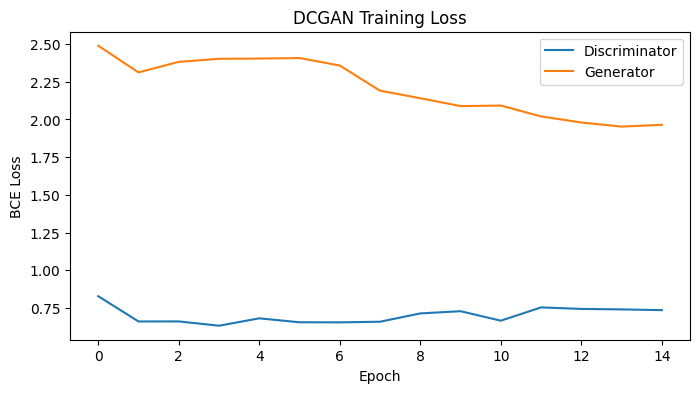

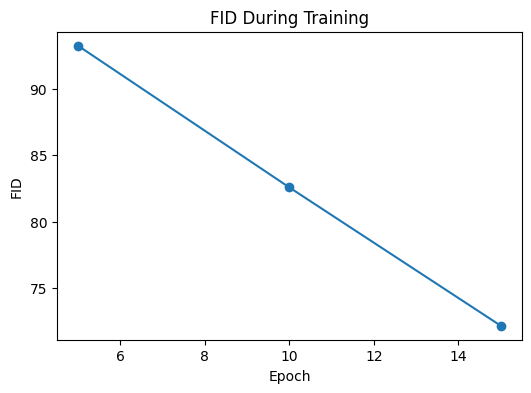

In [9]:
# Loss curves and FID
plt.figure(figsize=(8, 4))
plt.plot(hist_D_dc, label='Discriminator')
plt.plot(hist_G_dc, label='Generator')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('DCGAN Training Loss')
plt.legend()
plt.show()

if fid_scores_dc:
    plt.figure(figsize=(6, 4))
    plt.plot(fid_epochs_dc, fid_scores_dc, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('FID')
    plt.title('FID During Training')
    plt.show()

Loss curves show the discriminator stabilizing while the generator loss gradually decreases. The FID trend drops across checkpoints, indicating improving sample quality over training.

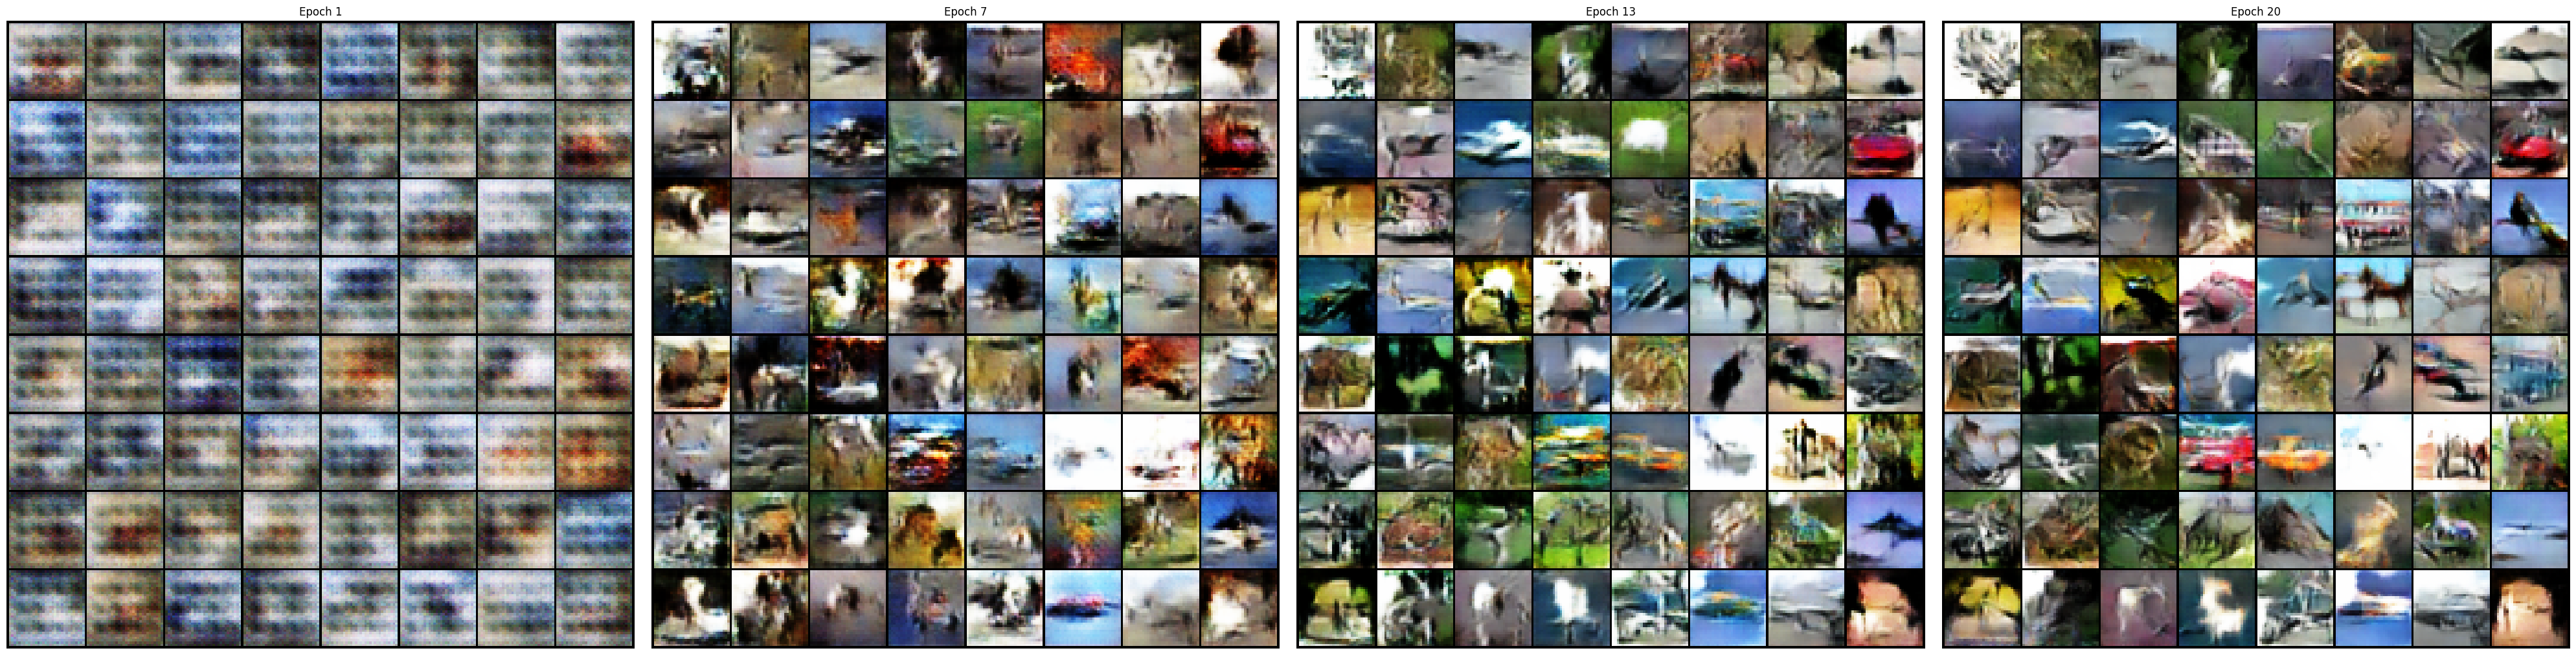

In [14]:
# 8x8 fixed-noise grids throughout training
num_snapshots = 4
snapshot_ids = np.linspace(0, len(fixed_fakes_dc) - 1, num_snapshots, dtype=int)
fig, axes = plt.subplots(1, num_snapshots, figsize=(10 * num_snapshots, 10))
if num_snapshots == 1:
    axes = [axes]
for ax, idx in zip(axes, snapshot_ids):
    grid = make_grid((fixed_fakes_dc[idx][:64] + 1) / 2, nrow=8, padding=1)
    ax.imshow(grid.permute(1, 2, 0).cpu().numpy())
    ax.set_title(f'Epoch {idx + 1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Fixed-noise snapshots progress from noisy textures to more structured CIFAR-like shapes and colors, showing consistent improvement with the same latent inputs.

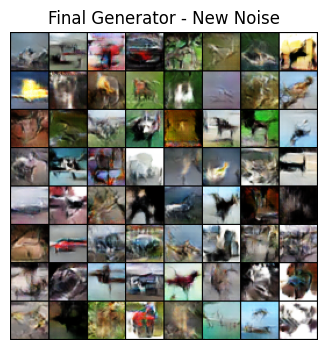

In [11]:
# New samples from final generator
netG_dc.eval()
with torch.no_grad():
    z_new = torch.randn(64, Z_DIM_DC, 1, 1, device=device)
    fake_new = netG_dc(z_new).cpu()
netG_dc.train()

grid = make_grid((fake_new + 1) / 2, nrow=8, padding=1)
plt.figure(figsize=(4, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis('off')
plt.title('Final Generator - New Noise')
plt.show()

Final samples from new noise are diverse and class-like, though some blur and artifacts remain at 32x32 resolution.

DCGAN challenges:  Training was sensitive to learning-rate balance and required careful choice of Adam betas; otherwise, the discriminator quickly overpowered the generator. FID estimation was noisy for small batches, so a larger sample size and periodic evaluation helped stabilize the metric. On MPS/CPU, FID computation is comparatively slow, so it was computed every few epochs rather than every epoch. Lastly, early epochs showed mode collapse tendencies that improved as the generator stabilized with fixed-noise monitoring.

## Problem 5.3: Anomaly Detection with VAE (30 points)
Use VAE for unsupervised anomaly detection:

• Train VAE on normal samples from credit card fraud dataset.

• Use reconstruction error as anomaly score.

• Compare with traditional anomaly detection methods (Isolation Forest,
One-Class SVM).

• Evaluate using precision-recall curves and ROC-AUC.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import keras as K
from keras.layers import Dense, Flatten
import tensorflow as tf

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

In [28]:
# load credit card fraud dataset; class 0 - normal, class 1 - fraud
df = pd.read_csv('data/creditcard.csv', index_col=0).reset_index(drop=True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
# train 80% of data where class is 0 only, test on remaining 20% of class 0 and all of class 1
df_class0 = df[df['Class'] == 0]
df_class1 = df[df['Class'] == 1]
train, test_class0 = train_test_split(df_class0, test_size=0.2, random_state=42)
test = pd.concat([test_class0, df_class1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle test set

X_train = train.drop('Class', axis=1).values
y_train = train['Class'].values
X_val = test_class0.drop('Class', axis=1).values
X_test = test.drop('Class', axis=1).values
y_test = test['Class'].values

# standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Custom VAE model (Keras)
class VAE(K.models.Model):
    def __init__(self, hidden_dim=128, latent_dim=8, kl_weight=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.kl_weight = kl_weight
        self.flatten = Flatten()
        self.encoder_dense = Dense(hidden_dim, activation='relu')
        self.mu_layer = Dense(latent_dim)
        self.log_var_layer = Dense(latent_dim)
        self.decoder_dense = Dense(hidden_dim, activation='relu')
        self.decoder_out = Dense(29, activation='linear')  # keep linear for scaled features

    def encode(self, x):
        x = self.flatten(x)
        h = self.encoder_dense(x)
        mu = self.mu_layer(h)
        log_var = self.log_var_layer(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        eps = tf.random.normal(shape=tf.shape(mu))
        sigma = tf.exp(0.5 * log_var)
        return mu + sigma * eps

    def decode(self, z):
        h = self.decoder_dense(z)
        return self.decoder_out(h)

    def call(self, inputs, training=False):
        mu, log_var = self.encode(inputs)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

    def _compute_loss(self, x, recon, mu, log_var):
        x_flat = tf.reshape(x, (-1, 29))
        recon_flat = tf.reshape(recon, (-1, 29))
        recon_error = tf.reduce_mean(tf.square(x_flat - recon_flat), axis=1)
        recon_loss = tf.reduce_mean(recon_error)
        kl = -0.5 * tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        kl_loss = tf.reduce_mean(kl)
        total_loss = recon_loss + self.kl_weight * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            recon, mu, log_var = self(x, training=True)
            total_loss, recon_loss, kl_loss = self._compute_loss(x, recon, mu, log_var)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        recon, mu, log_var = self(x, training=False)
        total_loss, recon_loss, kl_loss = self._compute_loss(x, recon, mu, log_var)
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

with tf.device('/GPU:0'):
    vae = VAE(hidden_dim=128, latent_dim=8, kl_weight=0.1)
    vae.compile(optimizer='adam')
    callbacks = [
        K.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
    history = vae.fit(
        X_train_scaled,
        epochs=50,
        batch_size=128,
        validation_data=X_val_scaled,
        callbacks=callbacks
    )


Epoch 1/50
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - kl_loss: 0.3057 - loss: 0.8728 - reconstruction_loss: 0.8422 - val_kl_loss: 0.2403 - val_loss: 0.7768 - val_reconstruction_loss: 0.7528
Epoch 2/50
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - kl_loss: 4.2539 - loss: 1.4547 - reconstruction_loss: 1.0294 - val_kl_loss: 2.0940 - val_loss: 0.9866 - val_reconstruction_loss: 0.7772
Epoch 3/50
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - kl_loss: 9.7498 - loss: 1.8925 - reconstruction_loss: 0.9175 - val_kl_loss: 15.0334 - val_loss: 2.3642 - val_reconstruction_loss: 0.8608
Epoch 4/50
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - kl_loss: 27.9519 - loss: 3.5845 - reconstruction_loss: 0.7893 - val_kl_loss: 30.6739 - val_loss: 3.7836 - val_reconstruction_loss: 0.7162
Epoch 5/50
1777/1777 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - kl_loss: 4.5744 - loss: 1.3877 - reconstruction_loss: 0.9303 - val_kl_loss: 3.7945 - val_loss: 1.0899 - val_reconstruction_loss: 0.7104
Epoch 6/50
1777/1777 ━━━━━━

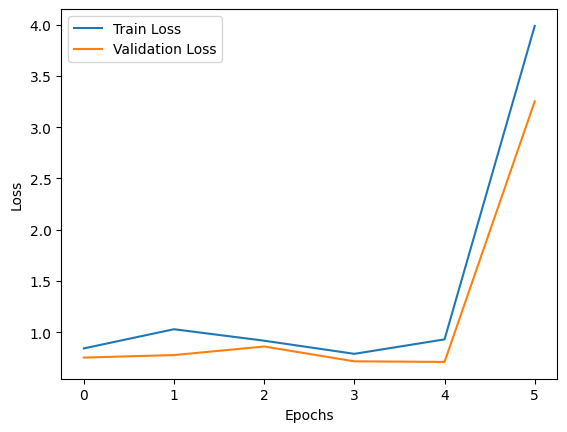

In [24]:
# plot train and validation loss
plt.plot(history.history['reconstruction_loss'], label='Train Loss')
plt.plot(history.history['val_reconstruction_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [20]:
# fit isolation forest and one class SVM
iso_forest = IsolationForest(contamination=0.01, random_state=42)
oc_svm = OneClassSVM(gamma='auto')

iso_forest.fit(X_train_scaled)
oc_svm.fit(X_train_scaled)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.5
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


VAE ROC AUC: 0.9545
Isolation Forest ROC AUC: 0.9491
One Class SVM ROC AUC: 0.9563


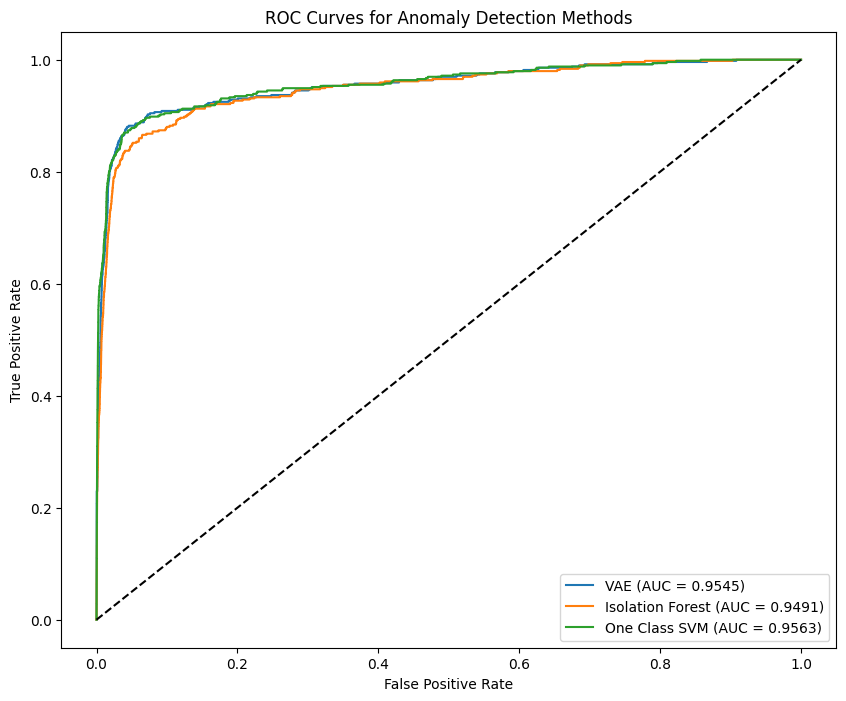

In [25]:
# compute reconstruction loss on test set and use it as anomaly score to compute ROC AUC for 3 methods
recon, mu, log_var = vae(X_test_scaled)
recon_error = tf.reduce_mean(tf.square(X_test_scaled - recon), axis=1)
kl = -0.5 * tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
vae_scores = (recon_error + vae.kl_weight * kl).numpy()  # combined score
iso_scores = iso_forest.decision_function(X_test_scaled)  # anomaly scores from isolation forest
svm_scores = oc_svm.decision_function(X_test_scaled)  # anomaly scores from one class SVM

vae_auc = roc_auc_score(y_test, vae_scores)
iso_auc = roc_auc_score(y_test, -iso_scores)  # higher score means more normal, so negate for AUC
svm_auc = roc_auc_score(y_test, -svm_scores)  # higher score means more normal, so negate for AUC
print(f'VAE ROC AUC: {vae_auc:.4f}')
print(f'Isolation Forest ROC AUC: {iso_auc:.4f}')
print(f'One Class SVM ROC AUC: {svm_auc:.4f}')

# plot ROC curves
fpr_vae, tpr_vae, _ = roc_curve(y_test, vae_scores)
fpr_iso, tpr_iso, _ = roc_curve(y_test, -iso_scores)
fpr_svm, tpr_svm, _ = roc_curve(y_test, -svm_scores)

plt.figure(figsize=(10, 8))
plt.plot(fpr_vae, tpr_vae, label=f'VAE (AUC = {vae_auc:.4f})')
plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {iso_auc:.4f})')
plt.plot(fpr_svm, tpr_svm, label=f'One Class SVM (AUC = {svm_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')  # FPR out of normal samples how many are incorrectly classified as anomalies
plt.ylabel('True Positive Rate')  # TPR out of fraud samples how many are correctly classified as anomalies
plt.title('ROC Curves for Anomaly Detection Methods')
plt.legend()
plt.show()


ROC curves are tightly clustered, so visual separation is minimal. The VAE and One-Class SVM are nearly overlapping, with Isolation Forest slightly below them; this suggests ROC AUC is high for all three but not very discriminative here. Because fraud is rare, ROC can look optimistic, and small visual gaps do not translate into meaningful precision at low recall.

VAE Average Precision: 0.4458
Isolation Forest Average Precision: 0.3836
One Class SVM Average Precision: 0.5250


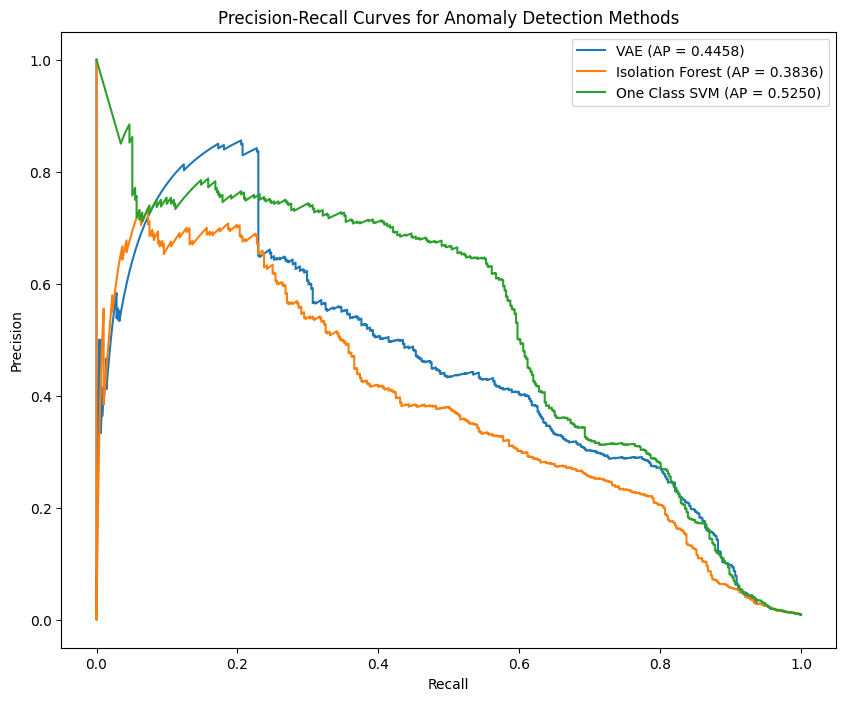

In [26]:
vae_ap = average_precision_score(y_test, vae_scores)
iso_ap = average_precision_score(y_test, -iso_scores)
svm_ap = average_precision_score(y_test, -svm_scores)
print(f'VAE Average Precision: {vae_ap:.4f}')
print(f'Isolation Forest Average Precision: {iso_ap:.4f}')
print(f'One Class SVM Average Precision: {svm_ap:.4f}')

# plot precision-recall curves
precision_vae, recall_vae, _ = precision_recall_curve(y_test, vae_scores)
precision_iso, recall_iso, _ = precision_recall_curve(y_test, -iso_scores)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, -svm_scores)

plt.figure(figsize=(10, 8))
plt.plot(recall_vae, precision_vae, label=f'VAE (AP = {vae_ap:.4f})')
plt.plot(recall_iso, precision_iso, label=f'Isolation Forest (AP = {iso_ap:.4f})')
plt.plot(recall_svm, precision_svm, label=f'One Class SVM (AP = {svm_ap:.4f})')
plt.xlabel('Recall')  # out of fraud samples how many are correctly classified as anomalies
plt.ylabel('Precision')  # out of samples classified as anomalies how many are actually fraud
plt.title('Precision-Recall Curves for Anomaly Detection Methods')
plt.legend()
plt.show()

Precision-recall is more informative under strong class imbalance. Here the VAE improves notably over Isolation Forest across much of the recall range, while One-Class SVM still leads in precision at mid-to-high recall. This indicates the VAE is capturing fraud patterns, even if it does not fully match the SVM at higher recall.